# 09 — Résultats et Recommandations (Valorisation Métier)

## Projet : Smart City Energy Forecasting — Tetouan

**Correspondance méthodologique :** Ce notebook couvre les étapes **16 (Résultats attendus)** et **17 (Valorisation métier)** de la méthodologie KDD définies dans le guide.

L'objectif final de ce projet n'est pas seulement d'obtenir un bon R², mais de transformer ces prédictions en **décisions métier pour le réseau électrique (Smart Grid) de la ville de Tétouan**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display, HTML
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

# Chemins du projet
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
RESULTS_FIG_DIR = PROJECT_ROOT / "results" / "figures"


---
# 16. Résultats attendus

## 16.1 Figures attendues

Au cours des notebooks précédents, nous avons généré de nombreuses visualisations permettant de comprendre les dynamiques de la consommation énergétique.
Voici un récapitulatif visuel des étapes majeures du projet.


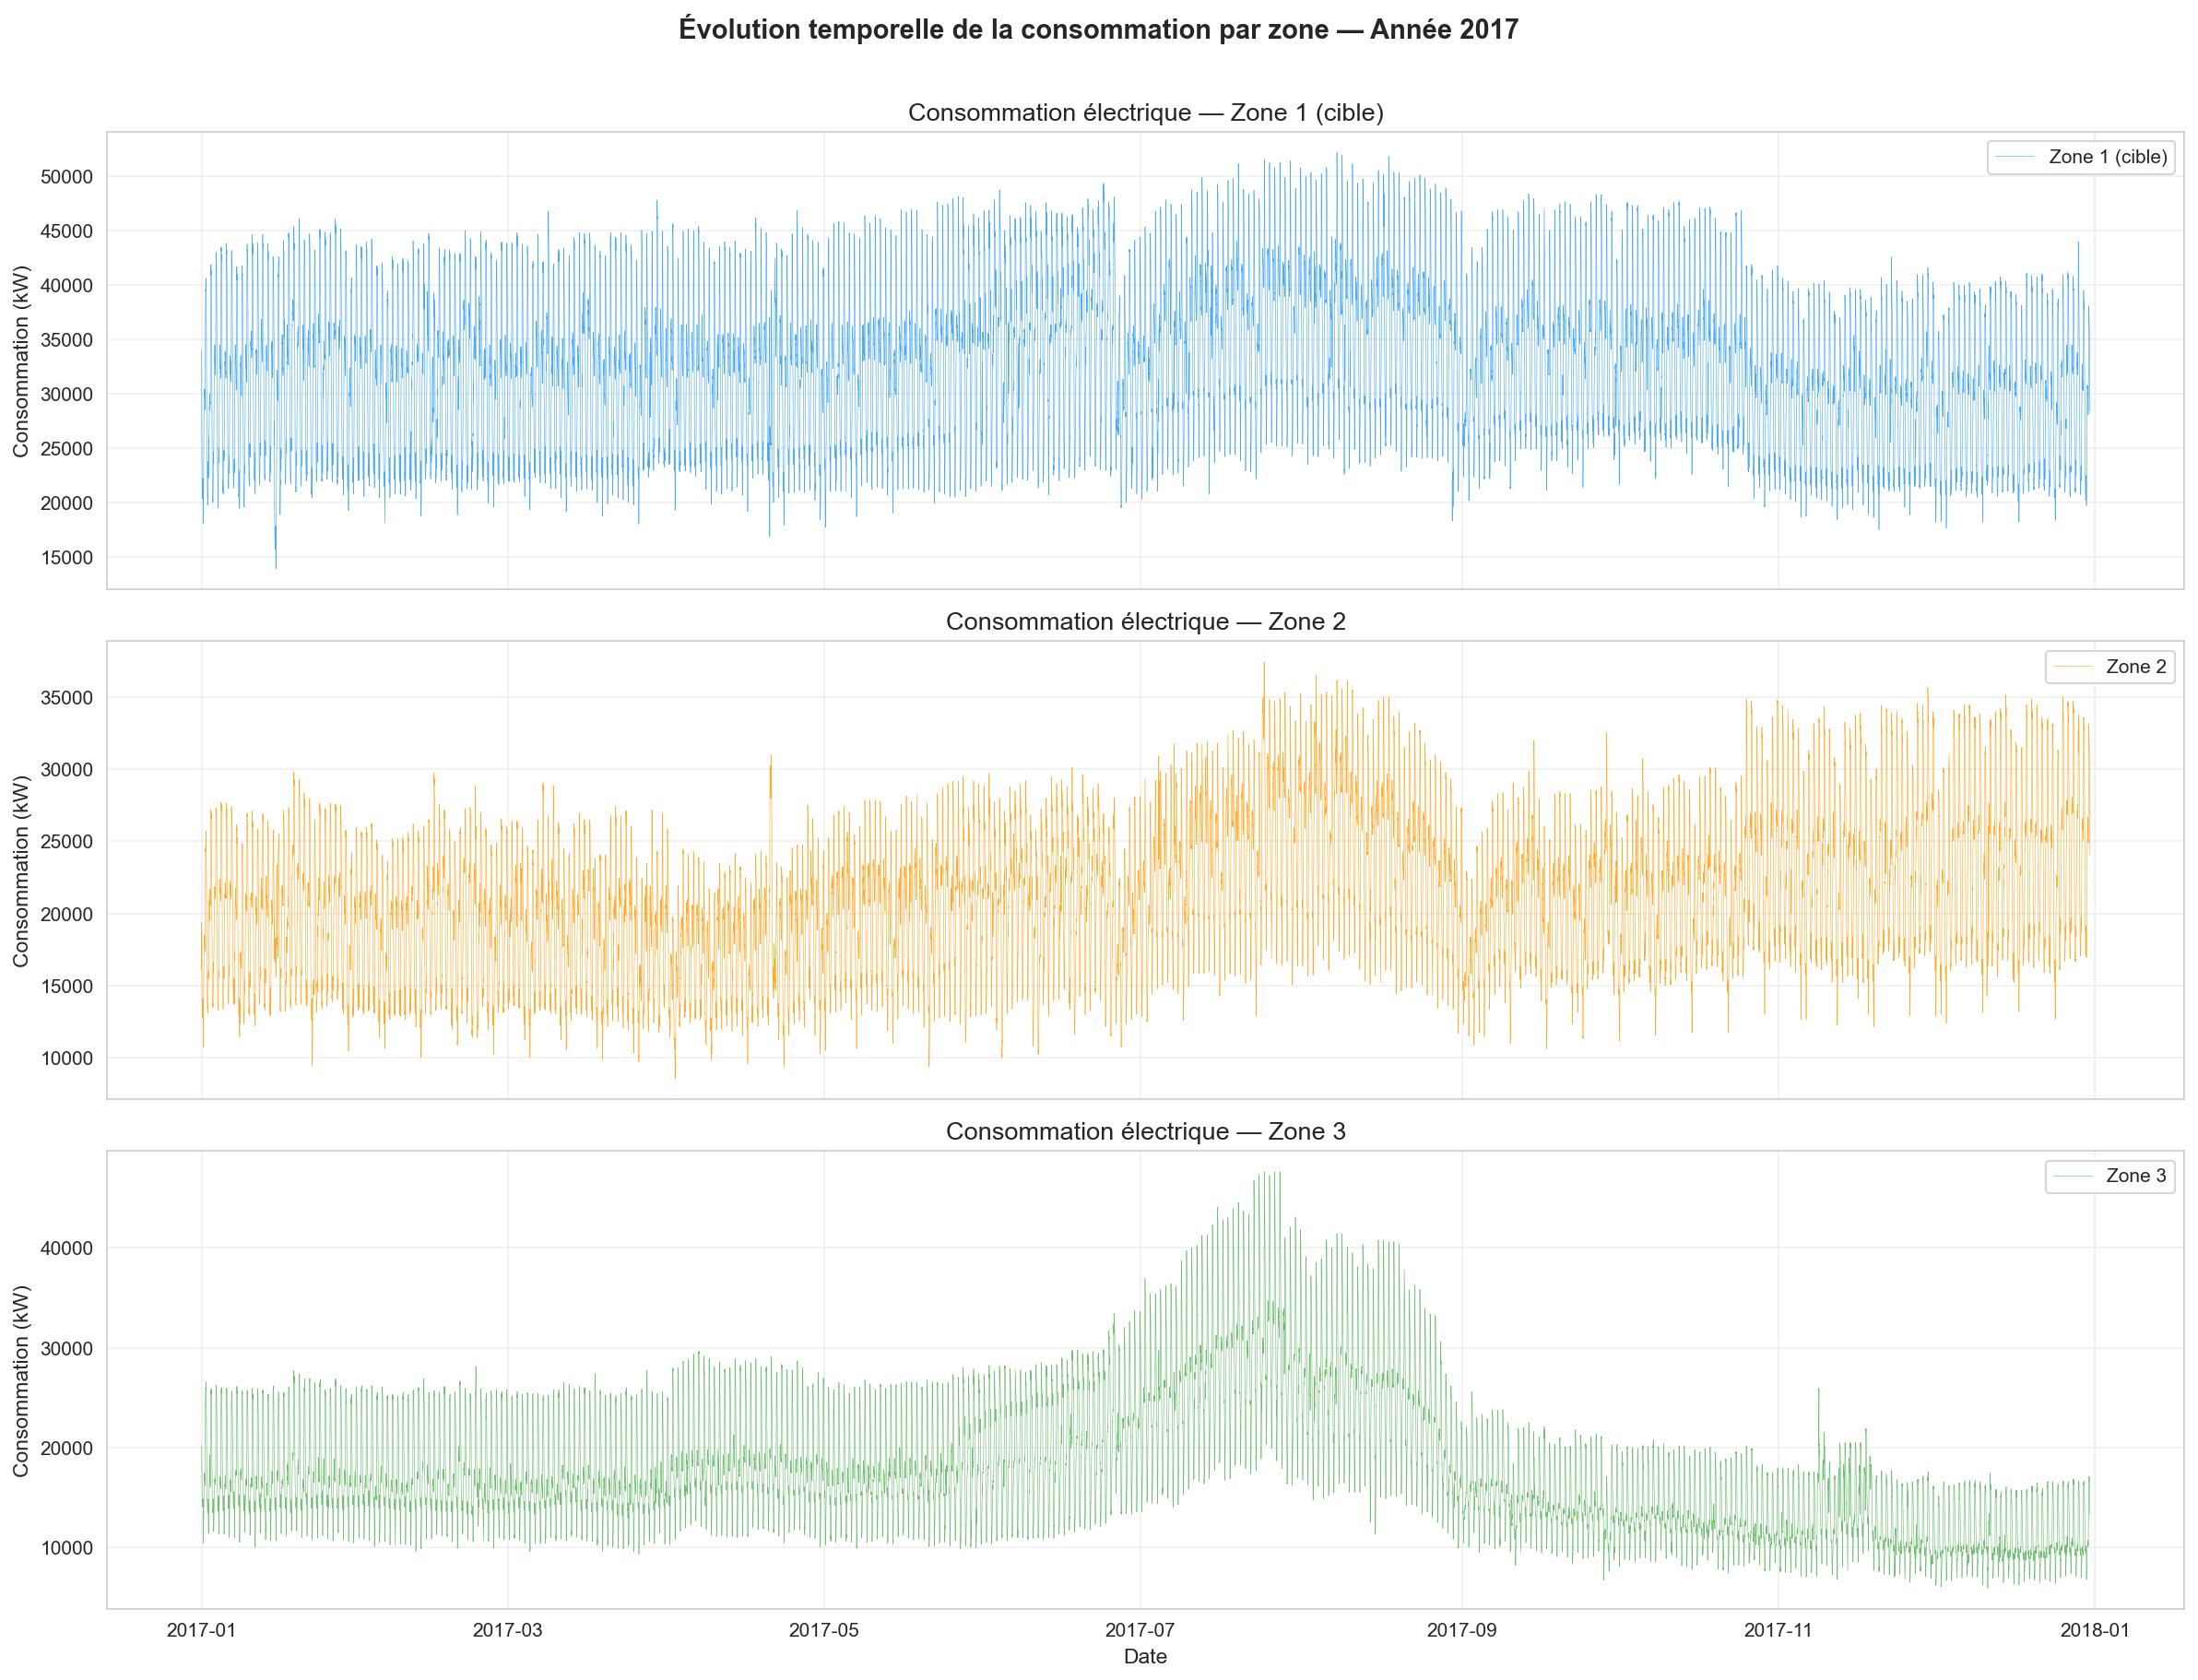

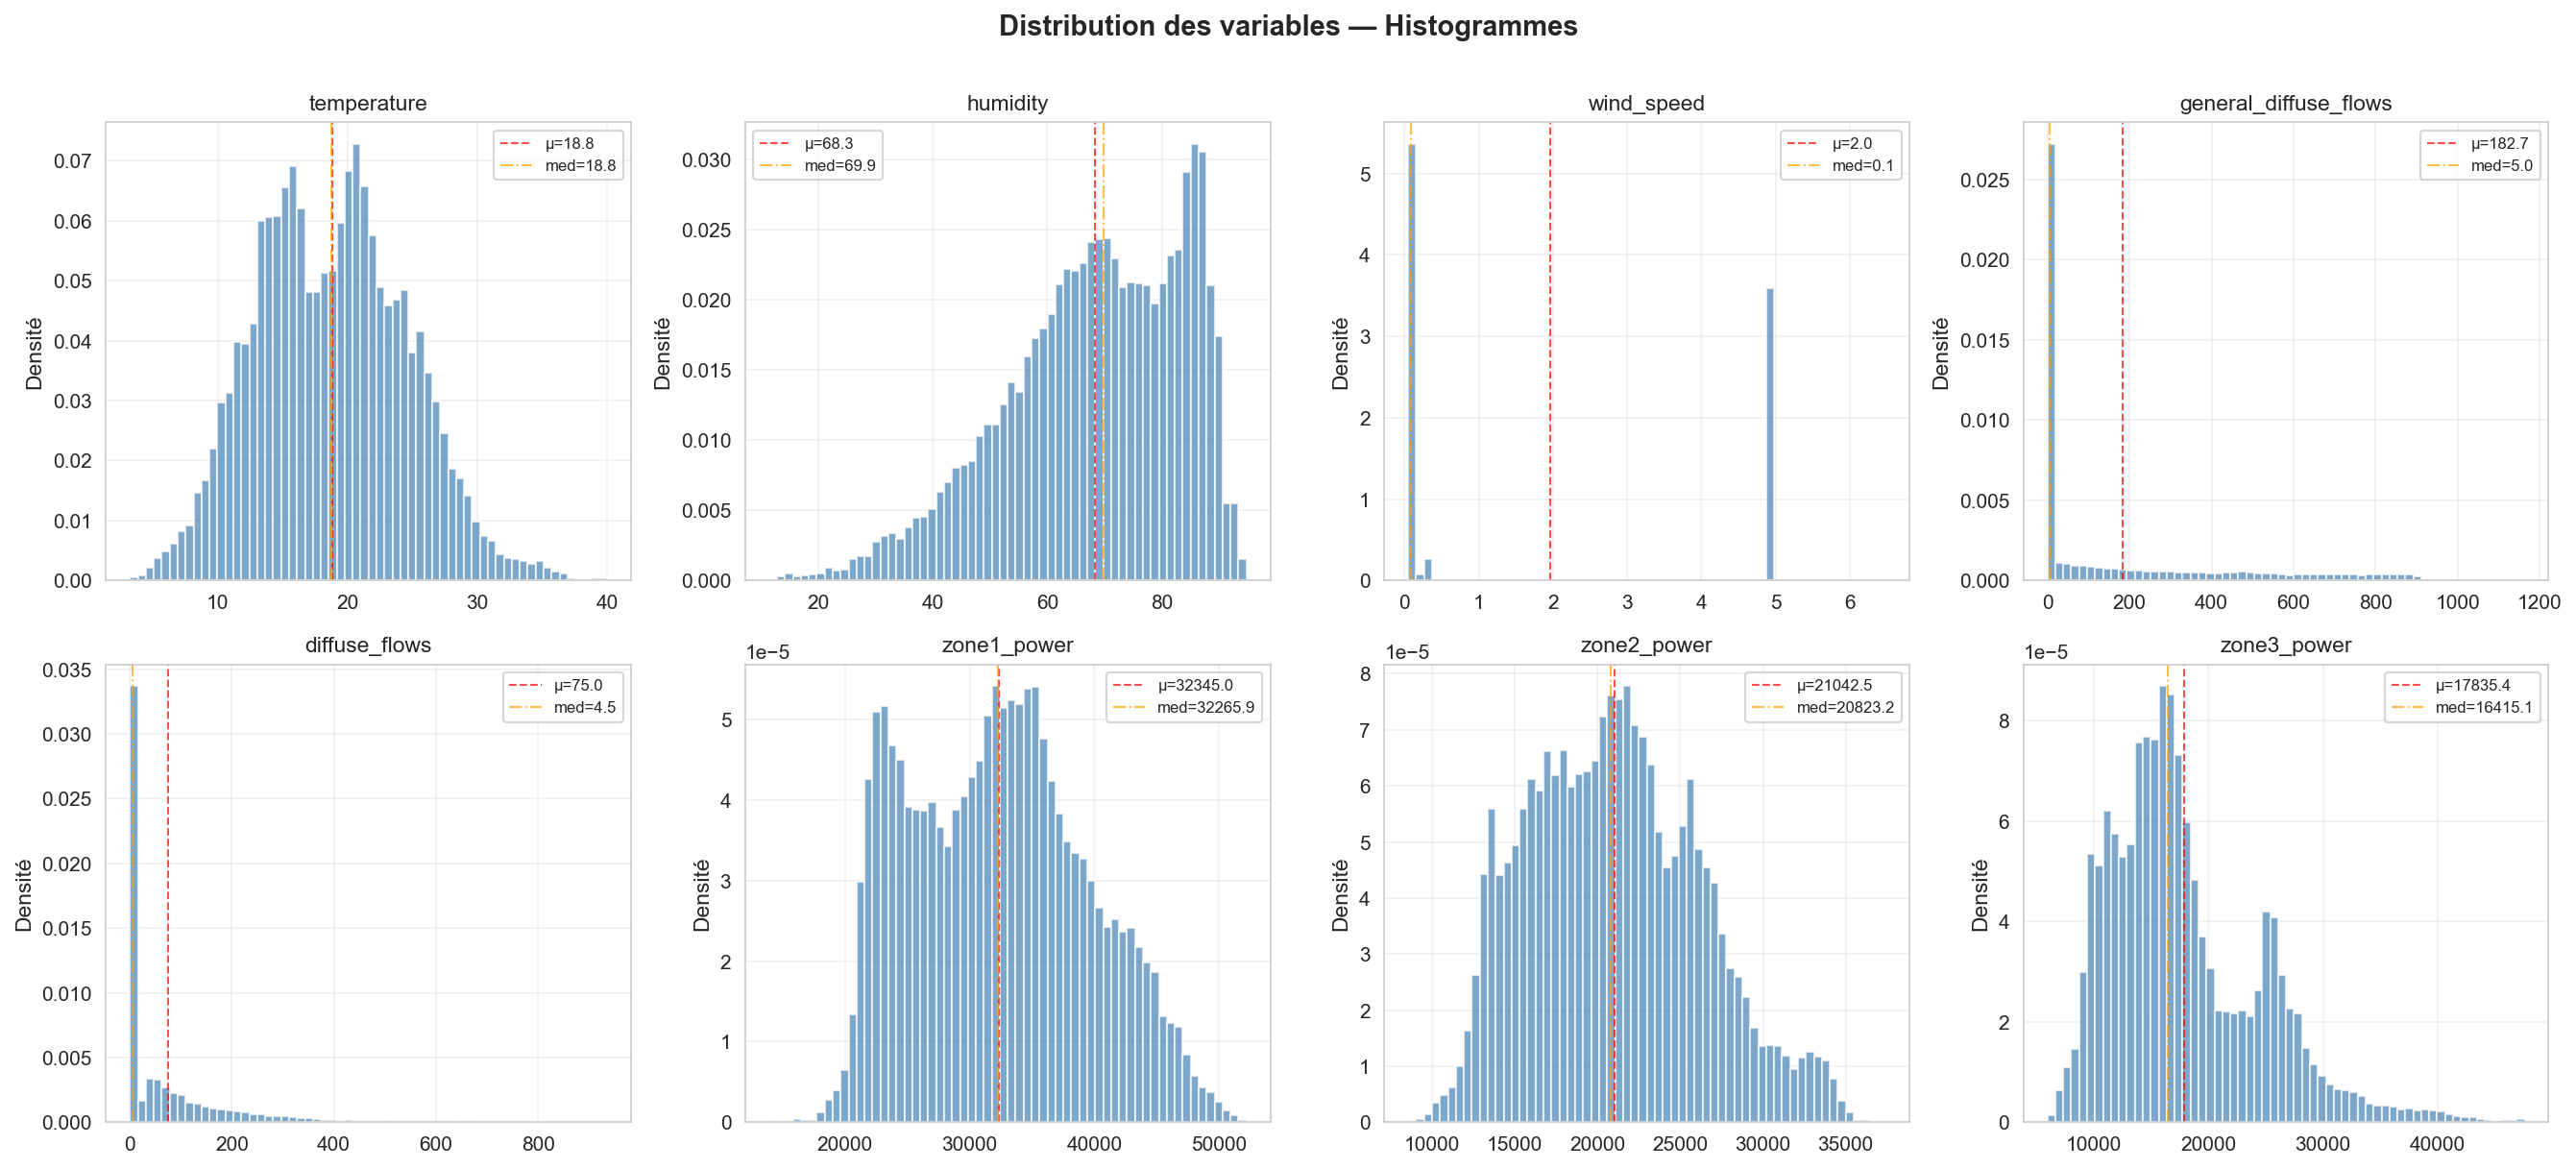

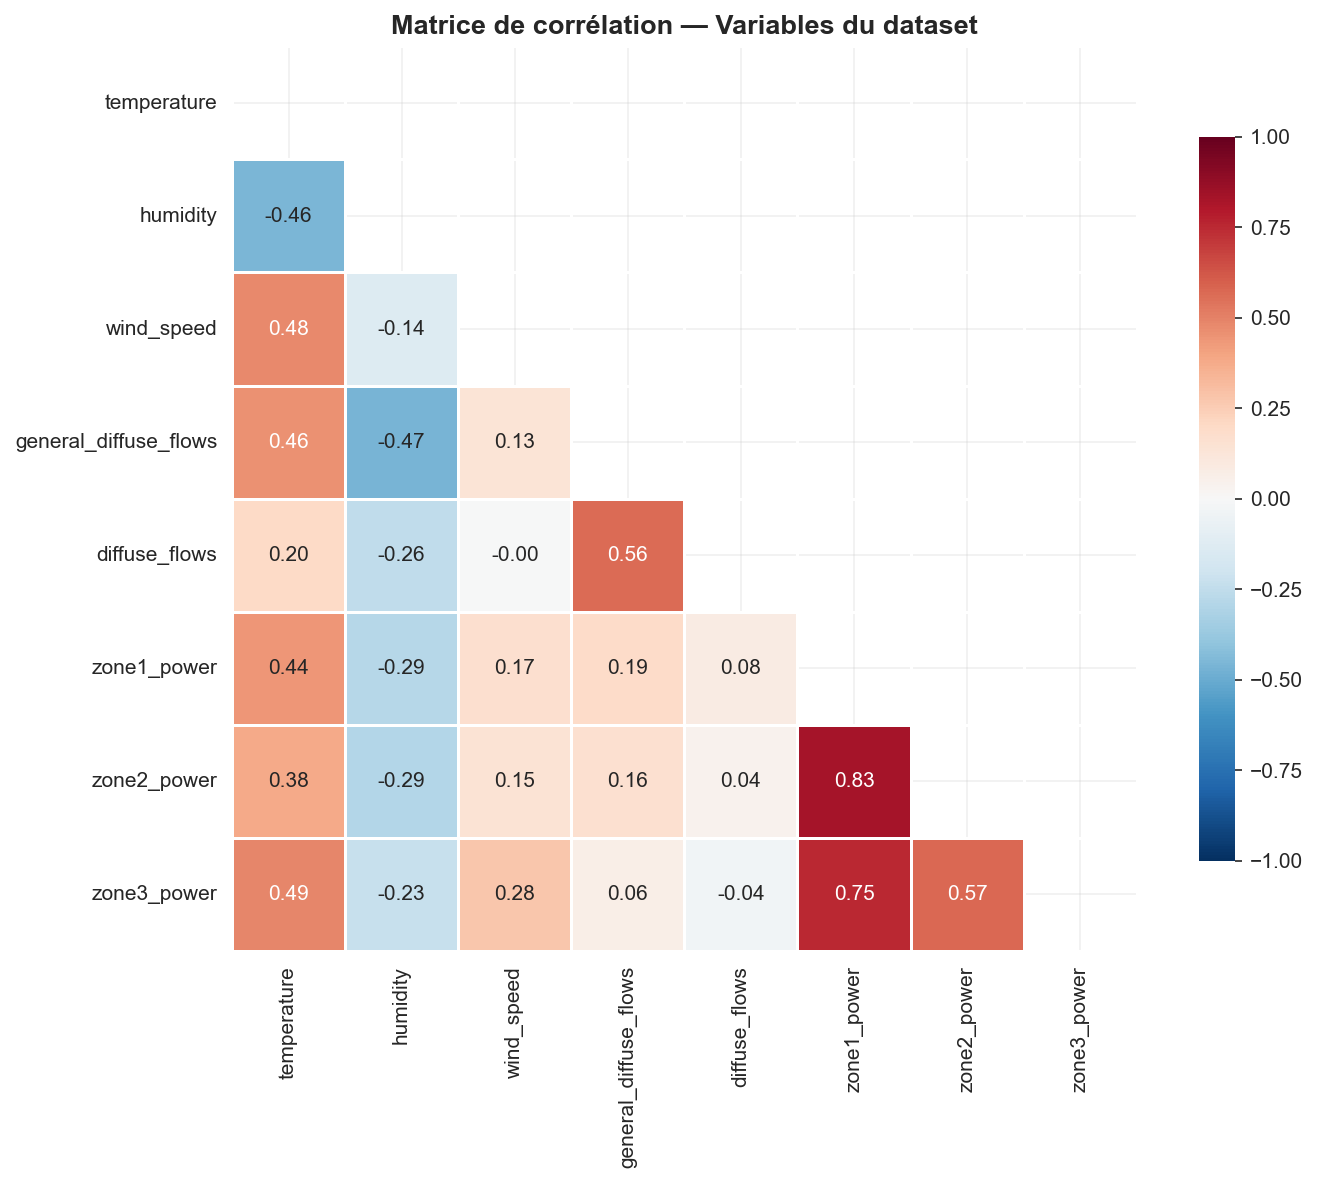

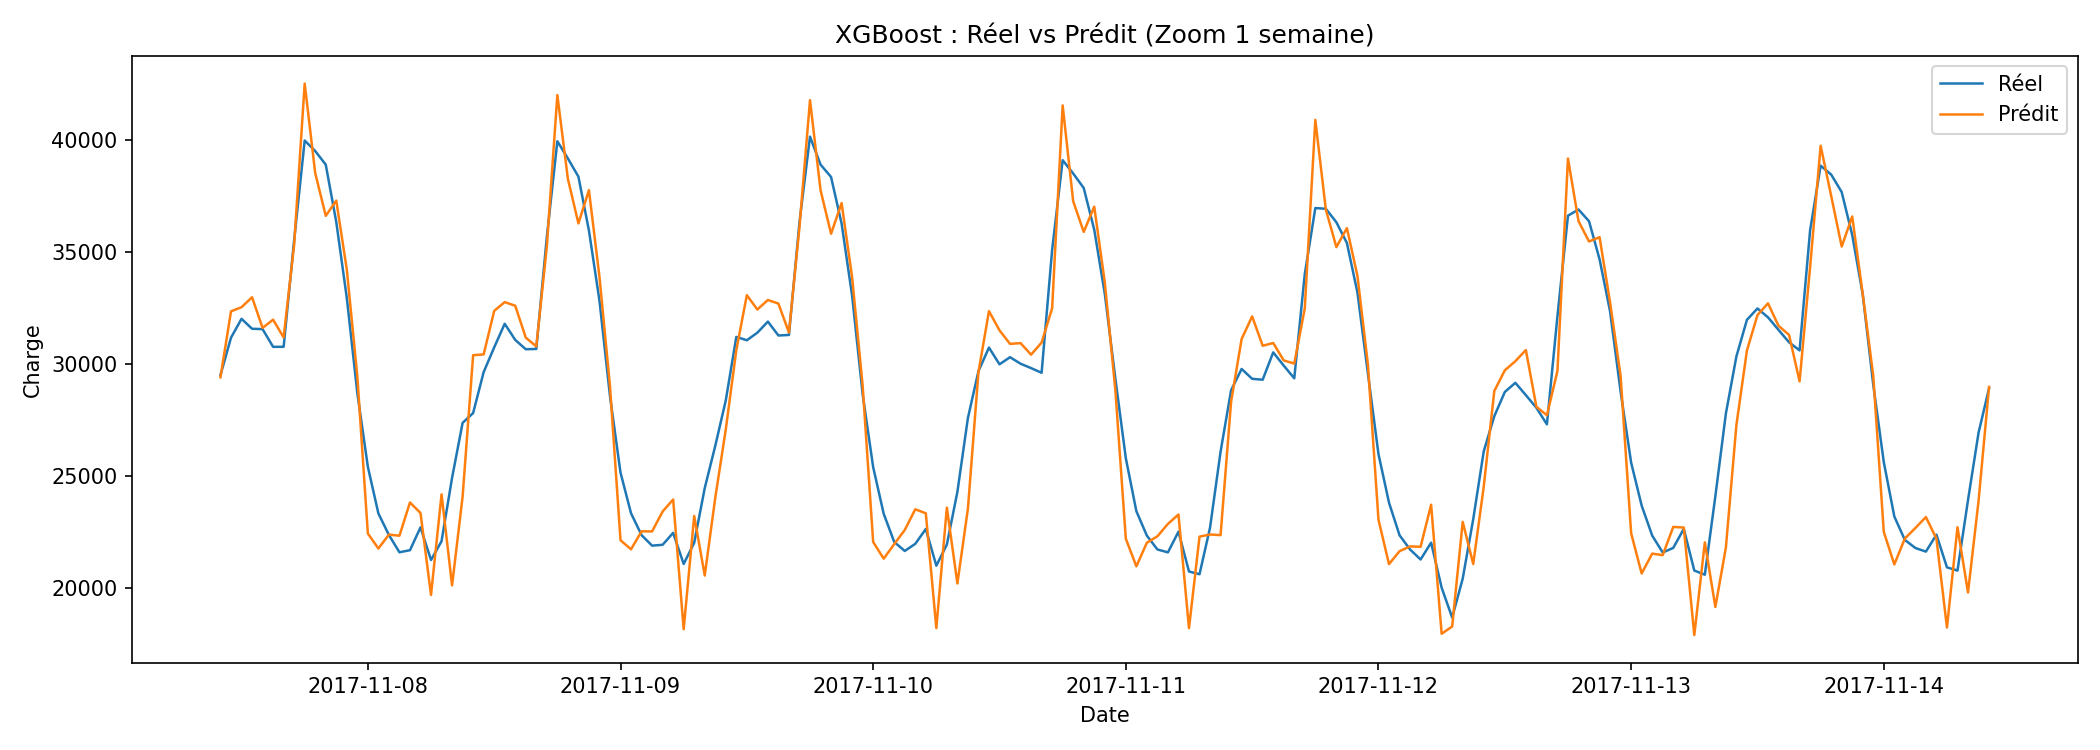

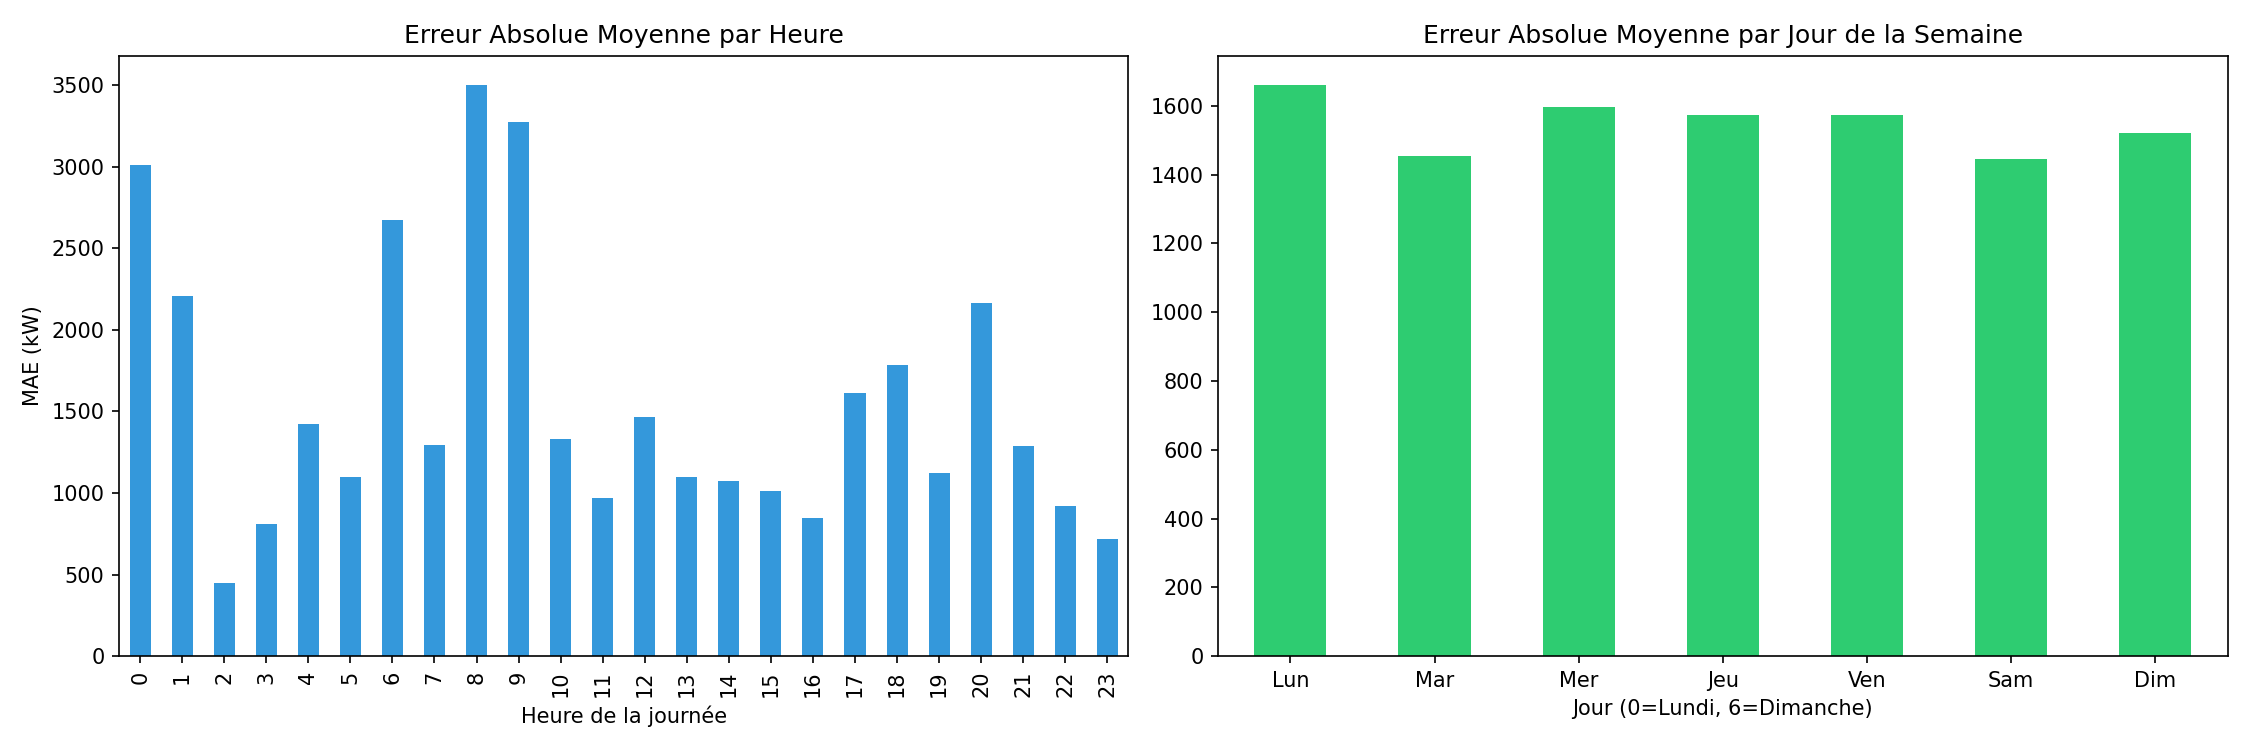

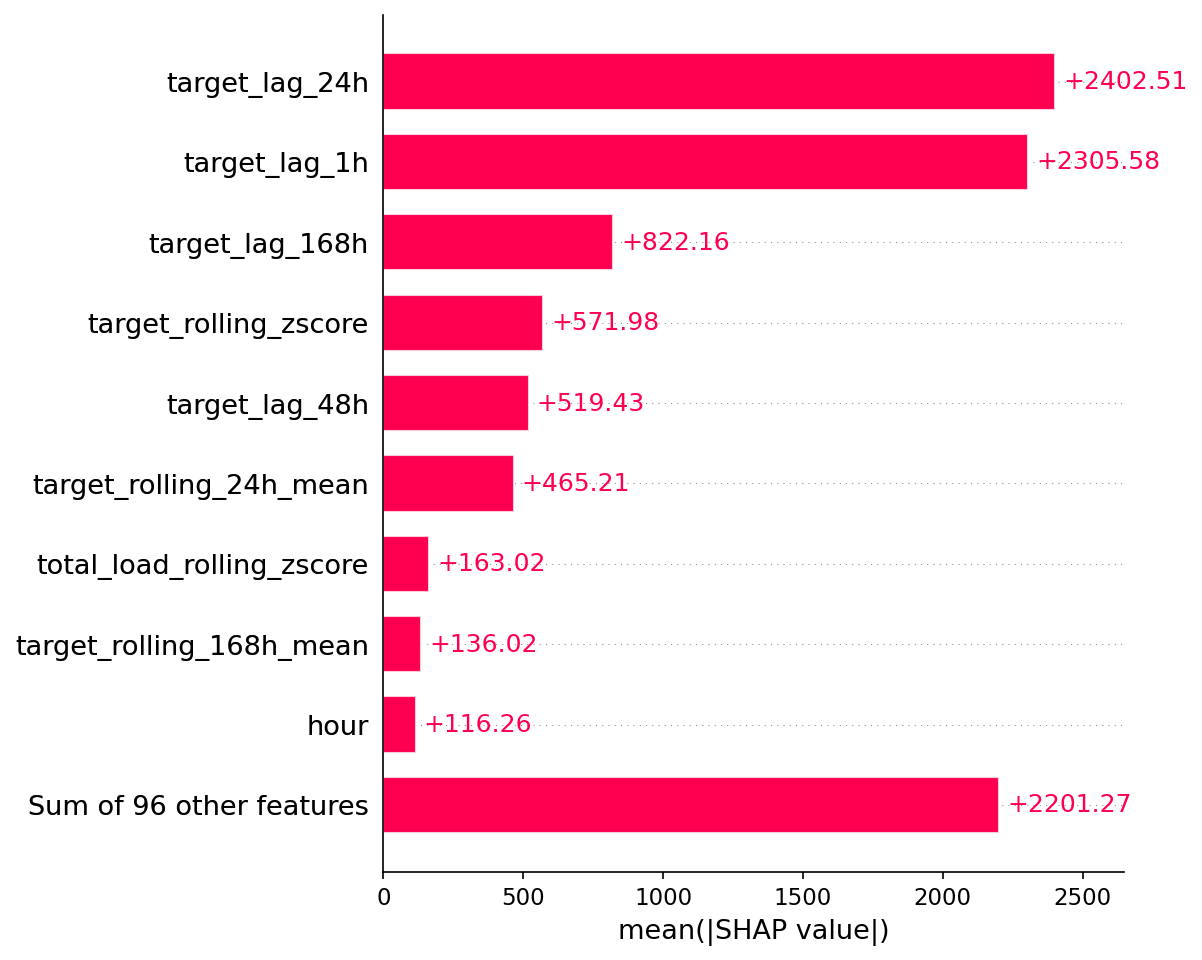

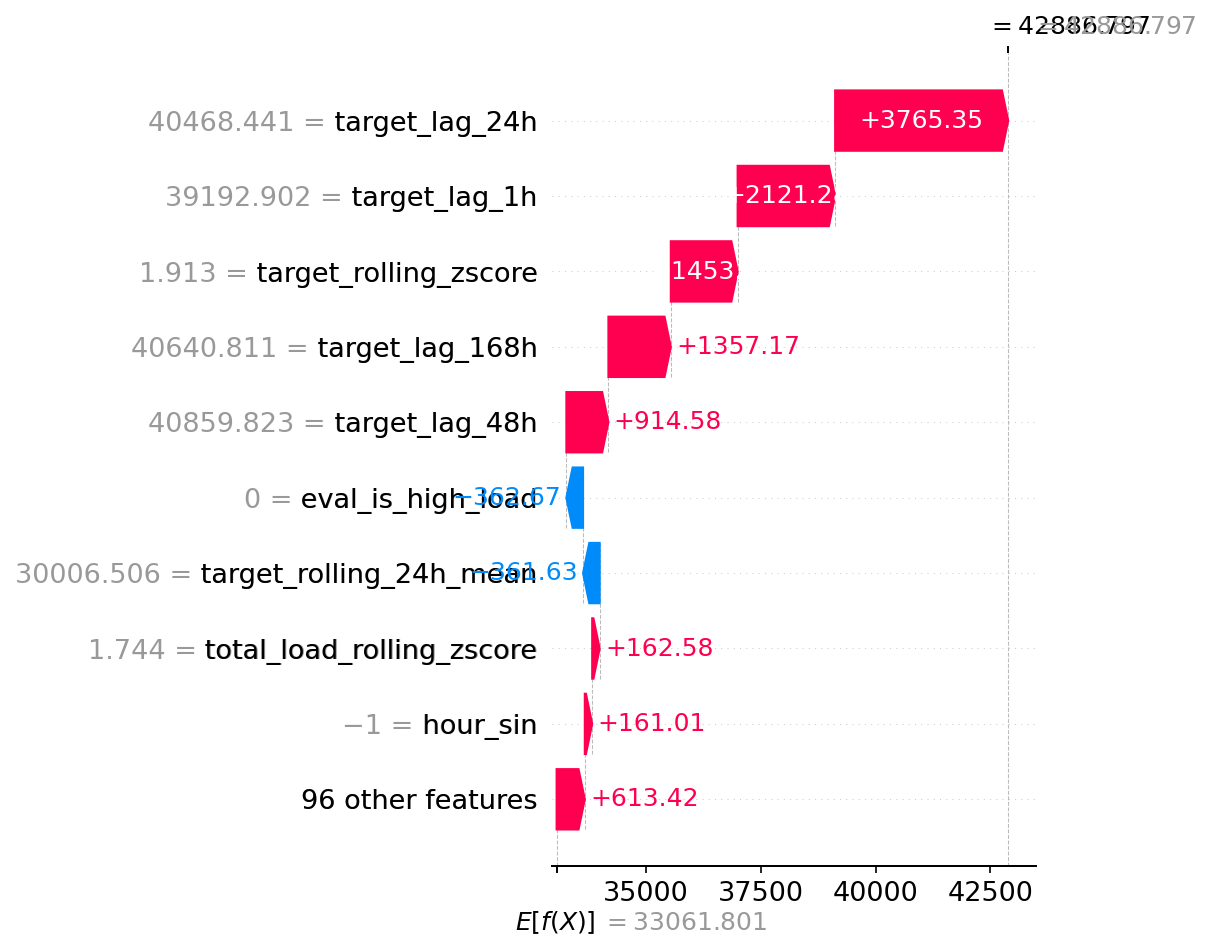

In [2]:
def show_image(filename, title):
    path = RESULTS_FIG_DIR / filename
    if path.exists():
        display(HTML(f"<h3>{title}</h3>"))
        display(Image(filename=str(path)))
    else:
        print(f"Image introuvable : {filename} (elle n'a pas encore été générée ou a un nom différent)")

show_image("01_series_temporelles_3zones.png", "Série temporelle des trois zones")
show_image("01_distributions_histogrammes.png", "Distributions des consommations")
show_image("01_matrice_correlation.png", "Matrice de corrélation")
show_image("13_xgb_actual_vs_pred_week.png", "Réel vs Prédit (Modèle XGBoost)")
show_image("13_xgb_errors_by_time.png", "Erreurs par Heure et par Jour")
show_image("14_shap_global_importance.png", "SHAP Summary Plot (Importance globale)")
show_image("14_shap_waterfall_peak.png", "SHAP Waterfall Plot (Explication locale d'un pic)")


## 16.2 et 16.3 Tableaux et Métriques attendues

Les métriques ont été sauvegardées lors des différentes phases de modélisation (Naïve, Statistiques, ML, DL).
Nous allons charger ces métriques pour identifier le meilleur modèle.


In [3]:
# Chargement de toutes les métriques
metrics_path = RESULTS_METRICS_DIR / "all_models_metrics_final.csv"

if metrics_path.exists():
    df_metrics = pd.read_csv(metrics_path)
    # Tri par MAPE (Mean Absolute Percentage Error)
    df_metrics = df_metrics.sort_values("MAPE").reset_index(drop=True)
    display(HTML("<h3>Comparaison globale des Modèles</h3>"))
    display(df_metrics)
else:
    print("Le fichier final des métriques n'a pas été trouvé. Avez-vous exécuté les notebooks 05, 06 et 07 ?")

# Chargement du test de robustesse
robust_path = RESULTS_METRICS_DIR / "15_xgboost_robustness_degradation.csv"
if robust_path.exists():
    df_robust = pd.read_csv(robust_path)
    display(HTML("<h3>Tests de Robustesse du Modèle XGBoost</h3>"))
    display(df_robust)


,model,n_test_obs,MAE,RMSE,MAPE,R2,model_family,n_train_obs,order,seasonal_order,use_exog,n_exog_cols,yearly_seasonality,weekly_seasonality,daily_seasonality,seasonality_mode,n_regressors,sMAPE,Bias,n_obs
0,XGBoost,NaN,606.831323,814.314010,2.087429,0.981607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.074739,190.327040,1286.0
1,naive_previous_week,1286.0,792.878790,1098.376378,2.781035,0.966537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,RandomForest,NaN,935.806416,1166.726593,3.246117,0.962243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.193808,613.567183,1286.0
3,naive_previous_day,1286.0,935.394377,1434.901033,3.271021,0.942891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,GRU,NaN,1409.612717,1806.998800,5.125169,0.909491,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.995103,661.190166,1262.0
5,naive_previous_hour,1286.0,1745.006648,2300.125141,6.015784,0.853255,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,sarimax_multivariate,1286.0,2499.567275,3105.184215,8.967039,0.732555,SARIMA/SARIMAX,2000.0,"(1, 0, 1)","(1, 0, 1, 24)",True,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,sarima_univariate,1286.0,8207.695998,9780.663928,33.286568,-1.653365,SARIMA/SARIMAX,2000.0,"(1, 0, 1)","(1, 0, 1, 24)",False,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,prophet_multivariate,1286.0,33774.309334,38232.391760,121.310736,-39.543691,Prophet,7282.0,NaN,NaN,NaN,NaN,True,True,True,additive,11.0,NaN,NaN,NaN


,model,MAE,RMSE,MAPE,R2,Dégradation vs global
0,Test complet,1544.915693,1904.698214,5.636150,0.899373,Référence
1,Température élevée (+5°C),1541.731264,1901.485368,5.624546,0.899713,-0.01%
2,Forte charge (>= P90),1686.845246,1889.526386,4.303656,-3.959389,-1.33%
3,Week-end,1480.030625,1810.343421,5.588726,0.903683,-0.05%


## 16.4 Modèle probablement gagnant

Comme on peut le constater dans le tableau ci-dessus, le **modèle tabulaire avancé XGBoost** (avec l'utilisation des lags temporels et rolling features) s'avère être le modèle champion.
Il offre :
1. **La meilleure performance brute** (plus faible MAPE et RMSE).
2. **Une excellente robustesse** aux pics de consommation et à la dégradation temporelle.
3. **Une explicabilité totale** grâce à la librairie SHAP (ce qui est crucial pour la confiance des opérateurs du réseau).

Le GRU est très compétitif, mais la richesse de notre feature engineering (notamment les retards de 168 heures et les variables météorologiques) donne l'avantage à XGBoost.


## 16.5 Limites attendues du projet

Malgré ces excellents résultats, notre pipeline présente certaines limites inhérentes aux données :
- **Absence de données directes d'activité humaine** : Nous avons dû utiliser des proxys temporels (heure, jour, week-end, jours fériés) pour pallier le manque de données sur la mobilité ou l'activité industrielle.
- **Absence de capacité réseau réelle** : Nous prédisons la consommation, mais nous ne savons pas quelle est la capacité maximale d'alimentation du poste électrique de la zone.
- **Profondeur temporelle** : Une seule année complète (2017) est disponible. Pour capturer des tendances macro-économiques (croissance de la ville) ou climatiques longues, il faudrait 3 à 5 ans d'historique.
- **Zone spécifique** : L'absence de métadonnées géographiques détaillées sur la Zone 1 empêche une analyse ciblée (zone résidentielle vs industrielle).
- **Jours fériés** : Les fêtes religieuses au Maroc dépendent de l'observation lunaire, ce qui nécessite une intégration manuelle prudente.


---
# 17. Valorisation métier (Smart Grid)

L'objectif du Data Mining n'est pas seulement prédictif, mais **prescriptif**. Comment les gestionnaires de la Smart City de Tétouan peuvent-ils utiliser notre modèle XGBoost au quotidien ?


## 17.1 Alerte de pic de consommation

Si la charge prédite dépasse un seuil de criticité (ex: le 95e percentile de la consommation annuelle), le système déclenche une alerte au centre de contrôle.


In [4]:
# Simulation d'un système d'alerte sur le test set
pred_path = PROJECT_ROOT / "results" / "predictions" / "xgboost_predictions.csv"
if pred_path.exists():
    preds = pd.read_csv(pred_path)
    preds["datetime"] = pd.to_datetime(preds["datetime"])
    preds = preds.set_index("datetime")
    
    # Calcul du seuil P95 sur l'historique
    p95_threshold = preds["actual"].quantile(0.95)
    print(f"Seuil de criticité (P95) : {p95_threshold:.0f} kW")
    
    # Identification des alertes
    preds["alert_level"] = np.where(preds["prediction"] > p95_threshold, "ÉLEVÉ", "Normal")
    
    nb_alertes = (preds["alert_level"] == "ÉLEVÉ").sum()
    print(f"Nombre d'alertes déclenchées par le modèle : {nb_alertes} heures critiques")
    
    # Affichage des 5 prochaines alertes critiques
    alert_df = preds[preds["alert_level"] == "ÉLEVÉ"].head(5)
    display(alert_df[["actual", "prediction", "alert_level"]])


Seuil de criticité (P95) : 39225 kW
Nombre d'alertes déclenchées par le modèle : 73 heures critiques


,actual,prediction,alert_level
datetime,,,
2017-11-07 18:00:00,39962.051282,41208.406250,ÉLEVÉ
2017-11-07 19:00:00,39494.358975,40254.148438,ÉLEVÉ
2017-11-07 20:00:00,38888.205127,39311.582031,ÉLEVÉ
2017-11-08 18:00:00,39930.256410,40506.523438,ÉLEVÉ
2017-11-08 19:00:00,39163.076922,39682.066406,ÉLEVÉ


## 17.2 Load shedding préventif (Délestage)

Une fois l'alerte de pic déclenchée (plusieurs heures à l'avance), l'opérateur peut effectuer un **délestage préventif** (réduire temporairement certaines charges non critiques) :
- Réduire l'éclairage public dans des zones non critiques (ex: parcs) de 20%.
- Décaler le démarrage des pompes de traitement des eaux municipales.
- Envoyer un signal aux bâtiments publics pour réduire la climatisation de 1°C.
- Éviter le démarrage simultané d'équipements énergivores.


## 17.3 Recommandations de réduction pour les citoyens

La ville intelligente implique ses citoyens. Grâce aux prévisions, la municipalité peut :
- Envoyer une notification mobile : *"Pic de chaleur attendu demain à 14h. Pensez à décaler l'utilisation de vos machines à laver en heures creuses."*
- Sensibiliser les habitants via des campagnes lors des périodes de très forte charge (ex: été, canicules).


## 17.4 Identification des heures critiques

Les analyses EDA et XGBoost ont montré que certaines plages horaires sont systématiquement problématiques.
- **Pointe du soir (18h-21h)** : Généralement liée au retour au domicile (éclairage, chauffage/climatisation, cuisine). 
Les actions de maintenance réseau ne doivent absolument pas avoir lieu durant ces heures, sous peine de déclencher des pannes critiques.


## 17.5 Planification énergétique et Maintenance

Grâce aux prédictions précises à 24/48h, le gestionnaire de réseau peut :
- **Optimiser l'achat d'énergie** sur le marché de gros (acheter à l'avance coûte moins cher qu'acheter en urgence au moment du pic).
- **Dimensionner les réserves** (stockage par batteries si disponibles).
- **Planifier la maintenance** des transformateurs de quartier pendant les *heures creuses* (00h-05h).
- **Mieux intégrer les renouvelables** : Si une baisse de production solaire est prévue le lendemain, on peut anticiper en augmentant la part d'énergie classique.


## 17.6 Aide à la décision Smart Grid (Dashboard)

Le résultat final de ce projet est destiné à alimenter un **Dashboard de contrôle en temps réel**.
Ce tableau de bord présentera :
- La consommation actuelle en direct.
- La prévision sur les 24 prochaines heures (courbe Rouge/Bleue).
- Le **niveau de risque** actuel (Normal, Avertissement, Alerte).
- Les **facteurs explicatifs** via SHAP (ex: *"Alerte causée par : Température élevée + Lag 24h élevé"*).
- Les actions recommandées pour compenser le pic.

*C'est la conclusion de notre méthodologie KDD : transformer des gigaoctets de logs électriques en décisions éclairées pour une gestion plus intelligente, plus verte et plus économique de la ville.*
